# **Name: Akash Badhautiya**

#**Roll no: 24AI60R43**



#Construct and Analyse Task Dependency Graph:


In [70]:
import json # importing the json

with open('tasks_dependencies.json', 'r') as f: # opening the json file
  data = json.load(f) # reading the file into dat

print(data) # printing the data


{'Task_0': [], 'Task_1': [], 'Task_2': [], 'Task_3': [], 'Task_4': ['Task_1', 'Task_0', 'Task_3'], 'Task_5': ['Task_2', 'Task_4'], 'Task_6': [], 'Task_7': [], 'Task_8': ['Task_6'], 'Task_9': ['Task_2', 'Task_4', 'Task_0', 'Task_5', 'Task_8'], 'Task_10': ['Task_3', 'Task_9'], 'Task_11': [], 'Task_12': ['Task_1'], 'Task_13': ['Task_1', 'Task_11', 'Task_4', 'Task_12'], 'Task_14': ['Task_2', 'Task_1', 'Task_8'], 'Task_15': [], 'Task_16': ['Task_10', 'Task_13', 'Task_4', 'Task_8'], 'Task_17': ['Task_1'], 'Task_18': ['Task_5'], 'Task_19': ['Task_12', 'Task_10', 'Task_11'], 'Task_20': ['Task_6', 'Task_10', 'Task_19', 'Task_8'], 'Task_21': ['Task_1', 'Task_4', 'Task_12'], 'Task_22': [], 'Task_23': ['Task_22', 'Task_10', 'Task_5'], 'Task_24': ['Task_1', 'Task_18', 'Task_23', 'Task_12'], 'Task_25': ['Task_20'], 'Task_26': ['Task_19', 'Task_14', 'Task_25'], 'Task_27': ['Task_18', 'Task_4', 'Task_24'], 'Task_28': [], 'Task_29': ['Task_5'], 'Task_30': ['Task_5', 'Task_1', 'Task_0'], 'Task_31': ['Ta

In [71]:
n=len(data) #checking the length of data
print(n)

200


In [72]:
import numpy as np # importing numpy

In [73]:
arr = np.zeros((n, n)) # creating a matrix of size len(data)*len(data) for making it adjacency matrix
print(arr)


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [74]:
for task_i in data: # looping through the data
#updating the adjacency matrix
  for task_j in data:
    if task_i in data[task_j]:
      i = int(task_i.split('_')[1])
      j = int(task_j.split('_')[1])
      arr[j][i] = 1

In [75]:
#checking the no of edges in the adjacency matrix
count =0

for i in range(200):
  for j in range(200):
    if arr[i][j] == 1:
      count+=1
print(count)

485


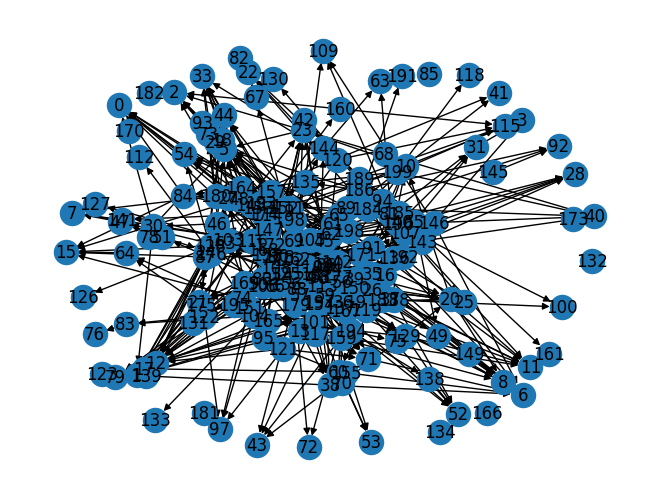

In [76]:
import networkx as nx # importing the networkx
import matplotlib.pyplot as plt #importing the matplotlib

G = nx.from_numpy_array(arr, create_using=nx.DiGraph) # creating the graph from the adjacency matrix
nx.draw(G, with_labels=True) # drawing the graph
plt.show() # showing the graph

In [77]:
# Defining the Topological Sorting function
def topological_sort(graph):

    in_degree_of_nodes = {node: graph.in_degree(node) for node in graph.nodes()} # calculating the in-degree of each node
    q = [node for node in graph.nodes() if in_degree_of_nodes[node] == 0] # creating a queue of nodes with in-degree 0
    result = [] # creating a result list
    while q:
        c_node = q.pop(0) # removing a node from the queue
        result.append(c_node) # adding the node to the result list
        for neigh in graph.neighbors(c_node): # for each neighbor of the node
          in_degree_of_nodes[neigh] -= 1 # decreasing the in-degree of the neighbor
          if in_degree_of_nodes[neigh] == 0: # if the in-degree of the neighbor is 0
            q.append(neigh) # add the neighbor to the queue
    if len(result) != len(graph.nodes()): # if the result list is not equal to the number of nodes in the graph
        raise ValueError("Graph has at least one cycle and topological sorting is not possible") # raise an error
    return result

In [78]:
# Calling the Topological sort function on the graph G
sorted_sequence = topological_sort(G)

# Printing the sequence of task completion
print("Sequence of task completed:", sorted_sequence)

Sequence of task completed: [68, 78, 82, 85, 117, 119, 120, 121, 123, 128, 131, 132, 134, 139, 142, 145, 149, 154, 155, 157, 158, 159, 162, 163, 166, 167, 170, 173, 175, 176, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 192, 193, 194, 195, 196, 197, 198, 199, 36, 148, 144, 147, 127, 126, 156, 104, 112, 153, 152, 58, 80, 100, 161, 169, 124, 130, 140, 146, 168, 137, 138, 165, 177, 143, 171, 172, 86, 151, 191, 118, 174, 122, 111, 113, 133, 39, 79, 110, 136, 106, 114, 101, 116, 129, 125, 150, 72, 93, 46, 64, 135, 141, 160, 164, 83, 97, 108, 63, 74, 75, 89, 96, 107, 77, 88, 90, 30, 62, 69, 109, 115, 57, 84, 76, 95, 98, 103, 70, 73, 102, 105, 71, 67, 37, 94, 99, 60, 34, 43, 45, 87, 92, 66, 91, 53, 56, 44, 81, 50, 51, 65, 21, 29, 40, 52, 33, 42, 59, 32, 47, 61, 16, 38, 7, 54, 55, 13, 48, 27, 28, 31, 35, 49, 15, 17, 41, 24, 26, 18, 23, 14, 25, 22, 20, 19, 10, 11, 12, 9, 5, 8, 2, 4, 6, 0, 1, 3]


In [79]:
class Strongly_ccs: # defining a class for finding the scc's
    def dfs(self, node, adj, vis, st): # defining a function for dfs
        vis[node] = 1 # marking the node as visited
        for neighbor in adj[node]: # for each neighbor of the node
            if not vis[neighbor]: # if the neighbor is not visited
                self.dfs(neighbor, adj, vis, st) # call the dfs function on the neighbor
        st.append(node) # add the node to the stack

    def dfs1(self, node, adjT, vis, scc_sequence): # defining a function for dfs1
        vis[node] = 1  # Mark the node as visited
        scc_sequence[-1].append(node)  # Add the node to the current SCC sequence
        for neighbor in adjT[node]:  # For each neighbor of the node
            if not vis[neighbor]:  # If the neighbor is not visited
                self.dfs1(neighbor, adjT, vis, scc_sequence)  # Call the dfs1 function on the neighbor

    # Function to find the number of strongly connected components in the graph
    def kosaraju(self, G): # defining a function for kosaraju
        V = len(G)  # Number of vertices in the graph
        adj = G  # Adjacency list representation of the graph

        vis = [0] * V  # List to mark visited vertices
        st = []  # Stack to store the order of vertices by their finish time

        # Step 1: Perform DFS and fill the stack with the order of nodes by their finish time
        for i in range(V):
            if not vis[i]:
                self.dfs(i, adj, vis, st)

        # Step 2: Transpose the graph
        adjT = [[] for _ in range(V)]
        for i in range(V):
            vis[i] = 0  # Reset the visited array for the second DFS
            for neighbor in adj[i]:
                adjT[neighbor].append(i)

        # Step 3: Perform DFS on the transposed graph in the order defined by the stack
        scc_sequence = []  # List to store the SCCs
        while st:
            node = st.pop()
            if not vis[node]:
                scc_sequence.append([])  # Start a new SCC
                self.dfs1(node, adjT, vis, scc_sequence)

        return scc_sequence  # Return the list of SCCs

In [80]:
solution=Strongly_ccs() # creating an object of the Strongly_cc class
scc_=solution.kosaraju(G) # calling the kosaraju function on the graph

# Print the strongly connected components
print("Strongly connected components:", scc_)

# Print the count of strongly connected components
print("Count of strongly connected components:", len(scc_))



Strongly connected components: [[199], [198], [197], [196], [195], [194], [193], [192], [191], [190], [189], [188], [187], [186], [185], [184], [183], [182], [181], [180], [179], [178], [177], [176], [175], [174], [173], [172], [171], [170], [169], [168], [167], [166], [165], [164], [163], [162], [161], [160], [159], [158], [157], [156], [155], [154], [153], [152], [151], [150], [149], [148], [147], [146], [145], [144], [143], [142], [141], [140], [139], [138], [137], [136], [135], [134], [133], [132], [131], [130], [129], [128], [127], [126], [125], [124], [123], [122], [121], [120], [119], [118], [117], [116], [115], [114], [113], [112], [111], [110], [109], [108], [107], [106], [105], [104], [103], [102], [101], [100], [99], [98], [97], [96], [95], [94], [93], [92], [91], [90], [89], [88], [87], [86], [85], [84], [83], [82], [81], [80], [79], [78], [77], [76], [75], [74], [73], [72], [71], [70], [69], [68], [67], [66], [65], [64], [63], [62], [61], [60], [59], [58], [57], [56], [55]

In [81]:
def find_strongly_connected_components(graph): # Defining the function to find the strongly connected components

  strongly_cc = list(nx.strongly_connected_components(graph)) # Finding the strongly connected components of the graph
  return strongly_cc # Returning the strongly connected components

# Find strongly connected components
scc = find_strongly_connected_components(G)



#Task 2


In [82]:
#Twitter Interaction Network for the US Congress:
#This network represents the Twitter interaction network for the 117th United States Congress,
#both the House of Representatives and Senate. The base data was collected via Twitter’s API;
# then the empirical transmission probabilities were quantified according to the fraction of times one member retweeted,
# quoted, tweeted, replied to, or mentioned another member’s tweet.
#All the files are given in the “congress_network” folder. Read the readme file for details.


In [83]:
#inList: list of lists such that inList[i] is a list of all the nodes sending connections TO node i
#inWeight: list of lists containing the connection weights (transmission probabilities) corresponding to the connections in inList
#outList: list of lists such that outList[i] is a list of all the nodes receiving connections FROM node i
#outWeight: list of lists containing the connection weights (transmission probabilities) corresponding to the connections in outList
#usernameList[i] gives the Twitter username corresponding to node i

In [84]:
import zipfile # importing the zipfile
with zipfile.ZipFile('congress_network.zip', 'r') as zip_data: # opening the zip file
    zip_data.extractall() # extracting the zip file


In [85]:
#reading json file
with open('/content/congress_network/congress_network_data.json', 'r') as f: # opening the json file
  data = json.load(f) # reading the file into data

In [86]:
print(data) # printing the data

[{'inList': [[4, 9, 11, 13, 18, 27, 29, 33, 38, 45, 46, 50, 57, 58, 59, 71, 74, 76, 77, 85, 86, 87, 202, 315, 341, 374], [11, 17, 20, 21, 22, 23, 26, 27, 31, 32, 39, 40, 51, 52, 57, 66, 67, 71, 73, 80, 89, 322], [13, 18, 21, 24, 36, 37, 42, 45, 50, 54, 56, 61, 64, 68, 71, 76, 79, 82, 85, 86, 87, 88, 90, 91, 118, 130, 162, 171, 178, 349, 368, 415, 463], [4, 8, 15, 19, 20, 22, 26, 30, 31, 32, 54, 72, 81, 83, 226, 385, 422, 449], [0, 3, 16, 24, 25, 27, 30, 37, 46, 48, 50, 53, 55, 56, 58, 59, 61, 64, 71, 77, 79, 86, 87, 88, 89, 149, 179, 243, 293, 401], [11, 13, 35, 42, 52, 55, 66, 77, 80, 89, 157], [29, 58, 61, 64], [11, 13, 17, 19, 21, 23, 26, 32, 35, 37, 39, 41, 44, 47, 49, 56, 68, 69, 77, 79, 80, 128, 249, 335, 439, 464, 471, 472], [3, 6, 7, 13, 15, 19, 20, 22, 31, 32, 33, 34, 38, 40, 47, 49, 51, 52, 59, 71, 72, 83, 91, 98, 105, 131, 192, 211, 324, 327, 333, 367, 382, 389, 428, 458], [2, 14, 15, 18, 24, 42, 46, 48, 55, 56, 61, 64, 65, 76, 79, 85, 87, 88, 90, 109, 126, 279, 394], [9, 50

In [87]:
InList=data[0]['inList'] # Reading the Inlist data into InList
InWeight=data[0]['inWeight'] # Reading the InWeight data into InWeight
OutList=data[0]['outList'] # Reading the OutList data into OutList
OutWeight=data[0]['outWeight'] # Reading the OutWeight data into OutWeight
UsernameList=data[0]['usernameList'] # Reading the UsernameList data into UsernameList


In [88]:
print(InList)


[[4, 9, 11, 13, 18, 27, 29, 33, 38, 45, 46, 50, 57, 58, 59, 71, 74, 76, 77, 85, 86, 87, 202, 315, 341, 374], [11, 17, 20, 21, 22, 23, 26, 27, 31, 32, 39, 40, 51, 52, 57, 66, 67, 71, 73, 80, 89, 322], [13, 18, 21, 24, 36, 37, 42, 45, 50, 54, 56, 61, 64, 68, 71, 76, 79, 82, 85, 86, 87, 88, 90, 91, 118, 130, 162, 171, 178, 349, 368, 415, 463], [4, 8, 15, 19, 20, 22, 26, 30, 31, 32, 54, 72, 81, 83, 226, 385, 422, 449], [0, 3, 16, 24, 25, 27, 30, 37, 46, 48, 50, 53, 55, 56, 58, 59, 61, 64, 71, 77, 79, 86, 87, 88, 89, 149, 179, 243, 293, 401], [11, 13, 35, 42, 52, 55, 66, 77, 80, 89, 157], [29, 58, 61, 64], [11, 13, 17, 19, 21, 23, 26, 32, 35, 37, 39, 41, 44, 47, 49, 56, 68, 69, 77, 79, 80, 128, 249, 335, 439, 464, 471, 472], [3, 6, 7, 13, 15, 19, 20, 22, 31, 32, 33, 34, 38, 40, 47, 49, 51, 52, 59, 71, 72, 83, 91, 98, 105, 131, 192, 211, 324, 327, 333, 367, 382, 389, 428, 458], [2, 14, 15, 18, 24, 42, 46, 48, 55, 56, 61, 64, 65, 76, 79, 85, 87, 88, 90, 109, 126, 279, 394], [9, 50, 59, 71, 77

In [89]:
print(InWeight)


[[0.0036496350364963502, 0.0036101083032490976, 0.004073319755600814, 0.0031446540880503146, 0.002347417840375587, 0.002512562814070352, 0.00641025641025641, 0.006024096385542169, 0.005208333333333333, 0.006711409395973154, 0.010238907849829351, 0.0022522522522522522, 0.0035460992907801418, 0.001303780964797914, 0.0025906735751295338, 0.0030911901081916537, 0.0014124293785310734, 0.009569377990430622, 0.002079002079002079, 0.0017241379310344827, 0.004454342984409799, 0.0038535645472061657, 0.0029850746268656717, 0.001669449081803005, 0.01680672268907563, 0.008620689655172414], [0.004073319755600814, 0.0005260389268805891, 0.007058823529411765, 0.007633587786259542, 0.0010695187165775401, 0.0023584905660377358, 0.0014749262536873156, 0.002512562814070352, 0.00398406374501992, 0.00186219739292365, 0.004132231404958678, 0.0035087719298245615, 0.02027027027027027, 0.005865102639296188, 0.0017730496453900709, 0.021739130434782608, 0.0051813471502590676, 0.0061823802163833074, 0.010266940451

In [90]:
print(OutList)


[[4, 12, 18, 25, 30, 46, 55, 58, 59, 74, 76, 77, 85, 86, 87, 154, 168, 341, 374, 401], [11, 15, 17, 20, 21, 30, 39, 51, 52, 66, 72, 80, 89, 142, 190, 192, 426, 428, 459], [9, 18, 24, 36, 37, 42, 64, 68, 73, 77, 85, 90, 91, 102, 130, 162, 171, 178, 189, 349, 368, 374], [4, 8, 17, 22, 32, 38, 39, 47, 50, 58, 62, 68, 72, 81, 83, 87, 92, 111, 113, 126, 165, 190, 203, 226, 242, 246, 288, 327, 335, 341, 349, 385, 401, 409, 435, 437, 461, 468], [0, 3, 12, 14, 17, 24, 25, 27, 30, 46, 55, 58, 59, 64, 79, 84, 88, 89, 149, 154, 168, 179, 197, 213, 224, 243, 250, 268, 286, 293, 315, 374, 401, 447, 460], [26, 35, 46, 55, 77, 80, 157, 242, 296, 306, 415, 460], [8, 29, 42, 54, 55, 58, 62, 64, 73, 91, 92, 145, 229, 296, 312, 366, 368, 390, 393], [8, 11, 17, 19, 21, 23, 26, 28, 32, 37, 39, 47, 54, 56, 68, 72, 74, 77, 79, 80, 83, 190, 249, 335, 464, 472], [3, 13, 15, 16, 17, 22, 25, 32, 33, 47, 52, 60, 66, 72, 80, 91, 95, 105, 131, 190, 192, 226, 271, 318, 382, 389, 428, 435, 458], [0, 10, 14, 15, 18, 2

In [91]:
print(OutWeight)


[[0.002105263157894737, 0.002105263157894737, 0.002105263157894737, 0.004210526315789474, 0.002105263157894737, 0.00631578947368421, 0.002105263157894737, 0.002105263157894737, 0.004210526315789474, 0.002105263157894737, 0.004210526315789474, 0.002105263157894737, 0.002105263157894737, 0.002105263157894737, 0.00631578947368421, 0.002105263157894737, 0.00631578947368421, 0.010526315789473684, 0.01263157894736842, 0.002105263157894737], [0.006309148264984227, 0.0031545741324921135, 0.0031545741324921135, 0.0031545741324921135, 0.006309148264984227, 0.0031545741324921135, 0.0031545741324921135, 0.012618296529968454, 0.0031545741324921135, 0.022082018927444796, 0.0031545741324921135, 0.0031545741324921135, 0.0031545741324921135, 0.0031545741324921135, 0.0031545741324921135, 0.0031545741324921135, 0.0031545741324921135, 0.0031545741324921135, 0.0031545741324921135], [0.0027247956403269754, 0.0027247956403269754, 0.0027247956403269754, 0.0326975476839237, 0.005449591280653951, 0.002724795640

In [92]:
print(UsernameList)

['SenatorBaldwin', 'SenJohnBarrasso', 'SenatorBennet', 'MarshaBlackburn', 'SenBlumenthal', 'RoyBlunt', 'CoryBooker', 'JohnBoozman', 'SenatorBraun', 'SenSherrodBrown', 'SenatorCantwell', 'SenCapito', 'SenatorCardin', 'SenatorCarper', 'SenBobCasey', 'SenBillCassidy', 'ChrisCoons', 'JohnCornyn', 'SenCortezMasto', 'SenTomCotton', 'SenKevinCramer', 'MikeCrapo', 'SenTedCruz', 'SteveDaines', 'SenDuckworth', 'SenatorDurbin', 'SenJoniErnst', 'SenFeinstein', 'SenatorFischer', 'SenGillibrand', 'LindseyGrahamSC', 'ChuckGrassley', 'SenatorHagerty', 'SenatorHassan', 'HawleyMO', 'MartinHeinrich', 'SenatorHick', 'maziehirono', 'SenJohnHoeven', 'SenHydeSmith', 'JimInhofe', 'SenRonJohnson', 'timkaine', 'SenMarkKelly', 'SenJohnKennedy', 'SenAngusKing', 'SenAmyKlobuchar', 'SenatorLankford', 'SenatorLeahy', 'SenMikeLee', 'SenatorLujan', 'SenLummis', 'Sen_JoeManchin', 'SenMarkey', 'SenatorMenendez', 'SenJeffMerkley', 'JerryMoran', 'lisamurkowski', 'ChrisMurphyCT', 'PattyMurray', 'ossoff', 'SenAlexPadilla', 

In [93]:
import networkx as nx # importing the networkx library
import matplotlib.pyplot as plt # importing the matplotlib library

In [94]:
Graph = nx.DiGraph() # creating a directed graph
for i in range(len(UsernameList)): # looping through the UsernameList
  Graph.add_node(i) # adding nodes to the graph


for i in range(len(OutList)): # looping through the OutList
  for j in OutList[i]: # looping through the OutList[i]
    Graph.add_edge(i, j) # adding edges to the graph


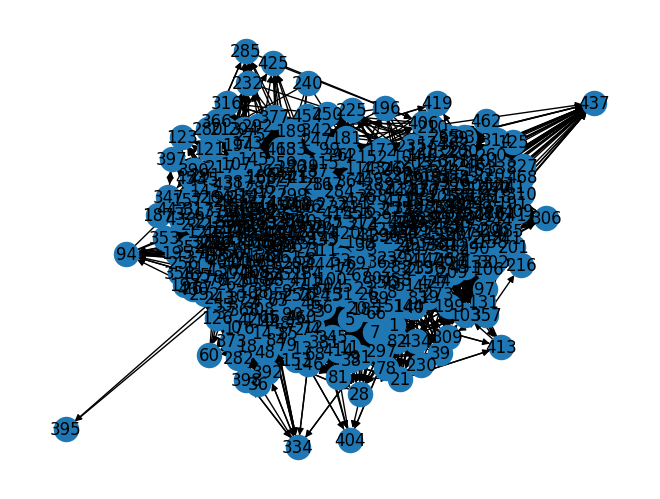

In [95]:
nx.draw(Graph, with_labels=True) # drawing the graph
plt.show() # showing the graph

In [96]:
class Strongly_ccs: # defining a class for finding the scc's
    def dfs(self, node, adj, vis, st): # defining a function for dfs
        vis[node] = 1 # marking the node as visited
        for neighbor in adj[node]: # for each neighbor of the node
            if not vis[neighbor]: # if the neighbor is not visited
                self.dfs(neighbor, adj, vis, st) # call the dfs function on the neighbor
        st.append(node) # add the node to the stack

    def dfs1(self, node, adjT, vis, scc_sequence): # defining a function for dfs1
        vis[node] = 1  # Mark the node as visited
        scc_sequence[-1].append(node)  # Add the node to the current SCC sequence
        for neighbor in adjT[node]:  # For each neighbor of the node
            if not vis[neighbor]:  # If the neighbor is not visited
                self.dfs1(neighbor, adjT, vis, scc_sequence)  # Call the dfs1 function on the neighbor

    # Function to find the number of strongly connected components in the graph
    def kosaraju(self, G): # defining a function for kosaraju
        V = len(G)  # Number of vertices in the graph
        adj = G  # Adjacency list representation of the graph

        vis = [0] * V  # List to mark visited vertices
        st = []  # Stack to store the order of vertices by their finish time

        # Step 1: Perform DFS and fill the stack with the order of nodes by their finish time
        for i in range(V):
            if not vis[i]:
                self.dfs(i, adj, vis, st)

        # Step 2: Transpose the graph
        adjT = [[] for _ in range(V)]
        for i in range(V):
            vis[i] = 0  # Reset the visited array for the second DFS
            for neighbor in adj[i]:
                adjT[neighbor].append(i)

        # Step 3: Perform DFS on the transposed graph in the order defined by the stack
        scc_sequence = []  # List to store the SCCs
        while st:
            node = st.pop()
            if not vis[node]:
                scc_sequence.append([])  # Start a new SCC
                self.dfs1(node, adjT, vis, scc_sequence)

        return scc_sequence  # Return the list of SCCs

In [97]:
S_cc = Strongly_ccs() # creating an object of the Strongly_cc class
Sccs = S_cc.kosaraju(Graph) # calling the kosaraju function on the graph
print("Strongly connected components (SCCs):", Sccs) # printing the scc's
print("Number of strongly connected components:", len(Sccs)) # printing the number of scc's

Strongly connected components (SCCs): [[456], [434], [356], [240], [227], [31], [0, 4, 3, 8, 6, 29, 51, 1, 11, 7, 13, 12, 14, 9, 2, 18, 17, 15, 20, 16, 27, 10, 50, 35, 5, 42, 36, 24, 25, 26, 23, 19, 49, 67, 73, 21, 22, 32, 30, 45, 33, 52, 43, 75, 57, 65, 71, 37, 59, 53, 48, 56, 47, 39, 38, 40, 28, 46, 54, 58, 60, 61, 55, 68, 63, 64, 66, 69, 70, 87, 72, 34, 41, 113, 95, 104, 127, 92, 81, 74, 44, 269, 98, 129, 102, 100, 136, 76, 148, 117, 85, 77, 80, 266, 137, 101, 105, 97, 175, 120, 322, 93, 162, 88, 84, 90, 119, 94, 110, 146, 151, 106, 203, 188, 83, 192, 99, 118, 116, 62, 198, 112, 140, 109, 96, 134, 124, 323, 160, 86, 143, 107, 108, 298, 149, 114, 164, 159, 161, 125, 141, 209, 190, 89, 168, 169, 202, 253, 103, 91, 131, 178, 184, 258, 259, 254, 121, 154, 135, 122, 147, 111, 115, 179, 171, 130, 132, 133, 211, 78, 423, 152, 234, 210, 220, 150, 206, 237, 208, 138, 155, 139, 128, 303, 142, 166, 195, 153, 156, 126, 79, 335, 158, 383, 172, 231, 294, 189, 200, 219, 185, 165, 245, 199, 251, 22

In [98]:
#Fuction for finding the All topological sorting
def topological_order(graph):

    in_degree_of_nodes = {node: graph.in_degree(node) for node in graph.nodes()} # calculating the in-degree of each node


    topological_sort_sequence=[] # creating a list to store all the topological orders
    visited = set() # creating a set to store the visited nodes

    def dfs(current_order):
        if len(current_order) == len(graph.nodes()): # if the current order is equal to the number of nodes in the graph
            topological_sort_sequence.append(current_order.copy()) # add the current order to the list of all orders
            print(current_order)
            return

        for node in graph.nodes(): # for each node in the graph
            if node not in visited and in_degree_of_nodes[node] == 0: # if the node is not visited and has an in-degree of 0
                visited.add(node) # add the node to the visited set
                current_order.append(node) # add the node to the current order

                for neigh in graph.neighbors(node): # for each neighbor of the node
                    in_degree_of_nodes[neigh] -= 1 # decrement the in-degree of the neighbor

                dfs(current_order) # recursively call the function with the updated current order

                visited.remove(node) # remove the node from the visited set
                current_order.pop() # remove the node from the current order

                for neigh in graph.neighbors(node): # for each neighbor of the node
                    in_degree_of_nodes[neigh] += 1 # increment the in-degree of the neighbor

    dfs([]) # call the dfs function with an empty current order
    return topological_sort_sequence # return the list of all orders

In [99]:
Topological_Sort=topological_order(Graph) # calling the topological_order function on the graph

In [100]:
#printing the sequence of topological sort
for i ,sequence in enumerate(Topological_Sort):

  print(f"Topological Sort {i+1}:", sequence)


here, cycle is present in the graph so zero topological order possible

In [101]:
print("No of topological sorting possible: ", len(Topological_Sort)) # printing the number of topological sorting

No of topological sorting possible:  0
